# Analiza skupa podataka Spotify Top 10000 u Google Colab okruženju

## Uvod

U ovom zadatku analiziram skup podataka **Spotify Top 10000** u Google Colab okruženju. Cilj analize je da prikažem osnovnu strukturu podataka, identifikujem najpopularnije pjesme, izdvojim izvođače sa najviše pjesama i ispitam kako se broj eksplicitnih pjesama mijenjao kroz vrijeme.

Podaci su preuzeti sa Kaggle platforme, a analiza i vizualizacija su urađene u Python okruženju koristeći biblioteke kao što su pandas, matplotlib i seaborn.

In [ ]:
# Ako je potrebno, instalacija biblioteke za preuzimanje sa Kaggle-a
!pip -q install kagglehub

# Uvoz biblioteka
import os
import glob
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Podešavanje izgleda grafikona
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Preuzimanje podataka

U ovom koraku preuzimam dataset **Spotify Top 10000** sa Kaggle platforme direktno u Google Colab koristeći biblioteku `kagglehub`.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("joebeachcapital/top-10000-spotify-songs-1960-now")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'top-10000-spotify-songs-1960-now' dataset.
Path to dataset files: /kaggle/input/top-10000-spotify-songs-1960-now


In [ ]:
import os
import glob

# Pronađi sve fajlove
all_files = glob.glob(os.path.join(path, "**", "*"), recursive=True)

# Pronađi CSV
csv_files = [f for f in all_files if f.endswith(".csv")]

print(csv_files)

['/kaggle/input/top-10000-spotify-songs-1960-now/top_10000_1960-now.csv', '/kaggle/input/top-10000-spotify-songs-1960-now/top_10000_1950-now.csv']


## Učitavanje skupa podataka

Nakon preuzimanja, učitavam CSV fajl u pandas DataFrame kako bi mogli izvršiti dalju analizu.

In [ ]:
df = pd.read_csv(csv_files[0])

print(df.shape)
df.head()

(9999, 35)


,Track URI,Track Name,Artist URI(s),Artist Name(s),Album URI,Album Name,Album Artist URI(s),Album Artist Name(s),Album Release Date,Album Image URL,...,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature,Album Genres,Label,Copyrights
0,spotify:track:1XAZlnVtthcDZt2NI1Dtxo,Justified & Ancient - Stand by the Jams,spotify:artist:6dYrdRlNZSKaVxYg5IrvCH,The KLF,spotify:album:4MC0ZjNtVP1nDD5lsLxFjc,Songs Collection,spotify:artist:6dYrdRlNZSKaVxYg5IrvCH,The KLF,1992-08-03,https://i.scdn.co/image/ab67616d0000b27355346b...,...,0.0480,0.0158,0.112000,0.4080,0.504,111.458,4.0,NaN,Jams Communications,"C 1992 Copyright Control, P 1992 Jams Communic..."
1,spotify:track:6a8GbQIlV8HBUW3c6Uk9PH,I Know You Want Me (Calle Ocho),spotify:artist:0TnOYISbd1XYRBk9myaseg,Pitbull,spotify:album:5xLAcbvbSAlRtPXnKkggXA,Pitbull Starring In Rebelution,spotify:artist:0TnOYISbd1XYRBk9myaseg,Pitbull,2009-10-23,https://i.scdn.co/image/ab67616d0000b27326d73a...,...,0.1490,0.0142,0.000021,0.2370,0.800,127.045,4.0,NaN,Mr.305/Polo Grounds Music/J Records,"P (P) 2009 RCA/JIVE Label Group, a unit of Son..."
2,spotify:track:70XtWbcVZcpaOddJftMcVi,From the Bottom of My Broken Heart,spotify:artist:26dSoYclwsYLMAKD3tpOr4,Britney Spears,spotify:album:3WNxdumkSMGMJRhEgK80qx,...Baby One More Time (Digital Deluxe Version),spotify:artist:26dSoYclwsYLMAKD3tpOr4,Britney Spears,1999-01-12,https://i.scdn.co/image/ab67616d0000b2738e4986...,...,0.0305,0.5600,0.000001,0.3380,0.706,74.981,4.0,NaN,Jive,P (P) 1999 Zomba Recording LLC
3,spotify:track:1NXUWyPJk5kO6DQJ5t7bDu,Apeman - 2014 Remastered Version,spotify:artist:1SQRv42e4PjEYfPhS0Tk9E,The Kinks,spotify:album:6lL6HugNEN4Vlc8sj0Zcse,"Lola vs. Powerman and the Moneygoround, Pt. On...",spotify:artist:1SQRv42e4PjEYfPhS0Tk9E,The Kinks,2014-10-20,https://i.scdn.co/image/ab67616d0000b2731e7c53...,...,0.2590,0.5680,0.000051,0.0384,0.833,75.311,4.0,NaN,Sanctuary Records,"C © 2014 Sanctuary Records Group Ltd., a BMG C..."
4,spotify:track:72WZtWs6V7uu3aMgMmEkYe,You Can't Always Get What You Want,spotify:artist:22bE4uQ6baNwSHPVcDxLCe,The Rolling Stones,spotify:album:0c78nsgqX6VfniSNWIxwoD,Let It Bleed,spotify:artist:22bE4uQ6baNwSHPVcDxLCe,The Rolling Stones,1969-12-05,https://i.scdn.co/image/ab67616d0000b27373d927...,...,0.0687,0.6750,0.000073,0.2890,0.497,85.818,4.0,NaN,Universal Music Group,"C © 2002 ABKCO Music & Records Inc., P ℗ 2002 ..."


## Osnovni pregled podataka

U ovom koraku provjeravam strukturu skupa podataka, nazive kolona, tipove podataka i prve redove tabele. Ovo mi omogućava da vidim koje kolone mogu koristiti za dalju analizu.

In [ ]:
print("Nazivi kolona:")
print(df.columns.tolist())

Nazivi kolona:
['Track URI', 'Track Name', 'Artist URI(s)', 'Artist Name(s)', 'Album URI', 'Album Name', 'Album Artist URI(s)', 'Album Artist Name(s)', 'Album Release Date', 'Album Image URL', 'Disc Number', 'Track Number', 'Track Duration (ms)', 'Track Preview URL', 'Explicit', 'Popularity', 'ISRC', 'Added By', 'Added At', 'Artist Genres', 'Danceability', 'Energy', 'Key', 'Loudness', 'Mode', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Time Signature', 'Album Genres', 'Label', 'Copyrights']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Track URI             9999 non-null   object 
 1   Track Name            9998 non-null   object 
 2   Artist URI(s)         9997 non-null   object 
 3   Artist Name(s)        9998 non-null   object 
 4   Album URI             9997 non-null   object 
 5   Album Name            9998 non-null   object 
 6   Album Artist URI(s)   9997 non-null   object 
 7   Album Artist Name(s)  9997 non-null   object 
 8   Album Release Date    9997 non-null   object 
 9   Album Image URL       9995 non-null   object 
 10  Disc Number           9999 non-null   int64  
 11  Track Number          9999 non-null   int64  
 12  Track Duration (ms)   9999 non-null   int64  
 13  Track Preview URL     7102 non-null   object 
 14  Explicit              9999 non-null   bool   
 15  Popularity           

In [ ]:
df.head()

,Track URI,Track Name,Artist URI(s),Artist Name(s),Album URI,Album Name,Album Artist URI(s),Album Artist Name(s),Album Release Date,Album Image URL,...,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature,Album Genres,Label,Copyrights
0,spotify:track:1XAZlnVtthcDZt2NI1Dtxo,Justified & Ancient - Stand by the Jams,spotify:artist:6dYrdRlNZSKaVxYg5IrvCH,The KLF,spotify:album:4MC0ZjNtVP1nDD5lsLxFjc,Songs Collection,spotify:artist:6dYrdRlNZSKaVxYg5IrvCH,The KLF,1992-08-03,https://i.scdn.co/image/ab67616d0000b27355346b...,...,0.0480,0.0158,0.112000,0.4080,0.504,111.458,4.0,NaN,Jams Communications,"C 1992 Copyright Control, P 1992 Jams Communic..."
1,spotify:track:6a8GbQIlV8HBUW3c6Uk9PH,I Know You Want Me (Calle Ocho),spotify:artist:0TnOYISbd1XYRBk9myaseg,Pitbull,spotify:album:5xLAcbvbSAlRtPXnKkggXA,Pitbull Starring In Rebelution,spotify:artist:0TnOYISbd1XYRBk9myaseg,Pitbull,2009-10-23,https://i.scdn.co/image/ab67616d0000b27326d73a...,...,0.1490,0.0142,0.000021,0.2370,0.800,127.045,4.0,NaN,Mr.305/Polo Grounds Music/J Records,"P (P) 2009 RCA/JIVE Label Group, a unit of Son..."
2,spotify:track:70XtWbcVZcpaOddJftMcVi,From the Bottom of My Broken Heart,spotify:artist:26dSoYclwsYLMAKD3tpOr4,Britney Spears,spotify:album:3WNxdumkSMGMJRhEgK80qx,...Baby One More Time (Digital Deluxe Version),spotify:artist:26dSoYclwsYLMAKD3tpOr4,Britney Spears,1999-01-12,https://i.scdn.co/image/ab67616d0000b2738e4986...,...,0.0305,0.5600,0.000001,0.3380,0.706,74.981,4.0,NaN,Jive,P (P) 1999 Zomba Recording LLC
3,spotify:track:1NXUWyPJk5kO6DQJ5t7bDu,Apeman - 2014 Remastered Version,spotify:artist:1SQRv42e4PjEYfPhS0Tk9E,The Kinks,spotify:album:6lL6HugNEN4Vlc8sj0Zcse,"Lola vs. Powerman and the Moneygoround, Pt. On...",spotify:artist:1SQRv42e4PjEYfPhS0Tk9E,The Kinks,2014-10-20,https://i.scdn.co/image/ab67616d0000b2731e7c53...,...,0.2590,0.5680,0.000051,0.0384,0.833,75.311,4.0,NaN,Sanctuary Records,"C © 2014 Sanctuary Records Group Ltd., a BMG C..."
4,spotify:track:72WZtWs6V7uu3aMgMmEkYe,You Can't Always Get What You Want,spotify:artist:22bE4uQ6baNwSHPVcDxLCe,The Rolling Stones,spotify:album:0c78nsgqX6VfniSNWIxwoD,Let It Bleed,spotify:artist:22bE4uQ6baNwSHPVcDxLCe,The Rolling Stones,1969-12-05,https://i.scdn.co/image/ab67616d0000b27373d927...,...,0.0687,0.6750,0.000073,0.2890,0.497,85.818,4.0,NaN,Universal Music Group,"C © 2002 ABKCO Music & Records Inc., P ℗ 2002 ..."


### Zaključak

Na osnovu početnog pregleda mogu da identifikujem kolone koje su važne za analizu, kao što su naziv pjesme, izvođač, popularnost, eksplicitnost i datum objavljivanja.

## Podešavanje naziva kolona

U ovom dijelu definišem nazive kolona koje ću koristiti u nastavku analize.

In [ ]:
artist_col = "Artist Name(s)"
track_col = "Track Name"
popularity_col = "Popularity"
release_date_col = "Album Release Date"
explicit_col = "Explicit"

## Osnovna analiza skupa podataka

U ovom dijelu računam ukupan broj pjesama i broj različitih izvođača u datasetu.

In [ ]:
broj_pjesama = df.shape[0]
broj_izvodjaca = df[artist_col].nunique()

print("Ukupan broj pjesama:", broj_pjesama)
print("Broj različitih izvođača:", broj_izvodjaca)

Ukupan broj pjesama: 9999
Broj različitih izvođača: 4129


### Zaključak

Skup podataka sadrži veliki broj pjesama i veliki broj različitih izvođača, što ga čini pogodnim za analizu popularnosti i muzičkih trendova.

## Top 5 pjesama po popularnosti

U ovom dijelu izdvajam pet pjesama sa najvećom vrednošću u koloni `Popularity`.

In [ ]:
top5_pjesama = df.sort_values(by=popularity_col, ascending=False).head(5)
top5_pjesama[[track_col, artist_col, popularity_col]].reset_index(drop=True)

,Track Name,Artist Name(s),Popularity
0,vampire,Olivia Rodrigo,98
1,Cupid - Twin Ver.,FIFTY FIFTY,97
2,Flowers,Miley Cyrus,96
3,I'm Good (Blue),"David Guetta, Bebe Rexha",95
4,I Ain't Worried,OneRepublic,95


### Zaključak

Sortiranjem po koloni `Popularity` dobijam pjesme koje imaju najveću vrijednost popularnosti u okviru posmatranog skupa. Ovaj rezultat pokazuje koje numere dominiraju po slušanosti i vidljivosti na platformi.

## Top 10 izvođača sa najviše pesama

U ovom koraku analiziram koji izvođači imaju najviše pjesama u datasetu. Za to koristim broj pojavljivanja svakog izvođača i prikazujem rezultat bar dijagramom.



In [ ]:
top10_izvodjaca = df[artist_col].value_counts().head(10)
top10_izvodjaca

,count
Artist Name(s),
Taylor Swift,48
P!nk,45
Elvis Presley,42
Ed Sheeran,40
The Beatles,39
Madonna,39
U2,39
The Rolling Stones,33
Queen,31


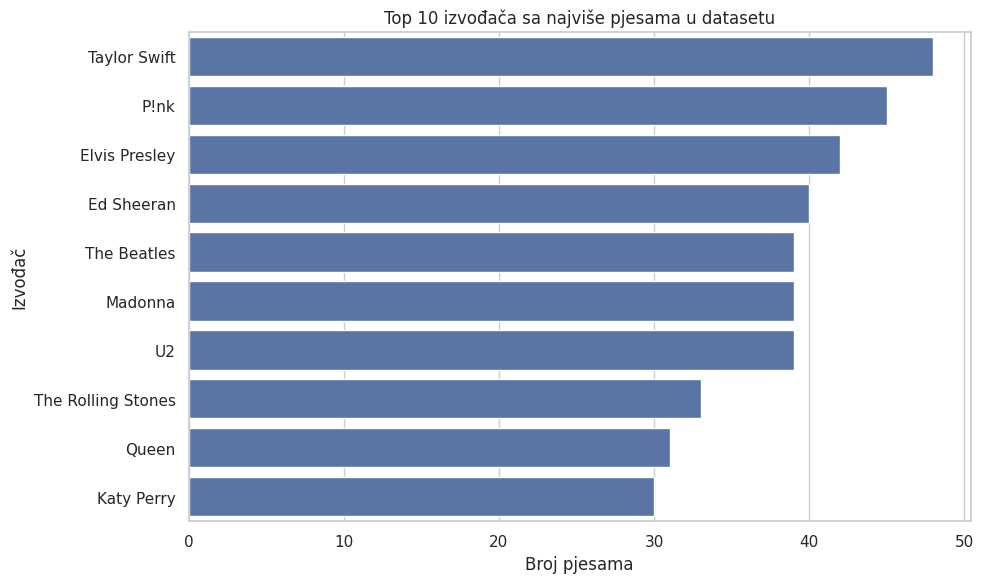

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top10_izvodjaca.values,
    y=top10_izvodjaca.index
)

plt.title("Top 10 izvođača sa najviše pjesama u datasetu")
plt.xlabel("Broj pjesama")
plt.ylabel("Izvođač")
plt.tight_layout()
plt.show()

### Zaključak

Bar dijagram jasno pokazuje koji izvođači imaju najveći broj pjesama u skupu podataka. Na ovaj način se lako uočavaju izvođači koji su najzastupljeniji i koji imaju najveću prisutnost u analiziranom izboru pjesama.

## Trend eksplicitnih pjesama kroz vrijeme

U ovom dijelu analiziram kako se broj eksplicitnih pjesama mijenjao kroz godine i decenije. Za ovu analizu koristim kolonu `Album Release Date`, iz koje izdvajam godinu objave, a zatim određujem deceniju kojoj svaka pjesma pripada.

In [ ]:
# Kopija dataframe-a radi sigurnijeg rada
df_trend = df.copy()

# Konverzija datuma
df_trend[release_date_col] = pd.to_datetime(df_trend[release_date_col], errors="coerce")

# Ekstrakcija godine
df_trend["Godina"] = df_trend[release_date_col].dt.year

# Provera nedostajućih godina
print("Broj nedostajućih godina:", df_trend["Godina"].isna().sum())

Broj nedostajućih godina: 1377


In [ ]:
# Pretvaranje kolone Explicit u string radi sigurnijeg filtriranja
df_trend[explicit_col] = df_trend[explicit_col].astype(str).str.upper()

# Filtriranje eksplicitnih pjesama
eksplicitne_pjesme = df_trend[df_trend[explicit_col] == "TRUE"].copy()

print("Broj eksplicitnih pjesama:", eksplicitne_pjesme.shape[0])

Broj eksplicitnih pjesama: 509


In [ ]:
# Uklanjanje redova bez godine
eksplicitne_pjesme = eksplicitne_pjesme.dropna(subset=["Godina"]).copy()
eksplicitne_pjesme["Godina"] = eksplicitne_pjesme["Godina"].astype(int)

# Određivanje decenije
eksplicitne_pjesme["Decenija"] = (eksplicitne_pjesme["Godina"] // 10) * 10

eksplicitne_pjesme[[track_col, "Godina", "Decenija"]].head()

,Track Name,Godina,Decenija
64,IDGAF,2017,2010
86,you broke me first,2020,2020
95,Billionaire (feat. Bruno Mars),2010,2010
109,working,2021,2020
115,Always On Time,2001,2000


In [ ]:
trend_eksplicitnih = (
    eksplicitne_pjesme
    .groupby("Decenija")
    .size()
    .reset_index(name="Broj eksplicitnih pjesama")
    .sort_values("Decenija")
)

trend_eksplicitnih

,Decenija,Broj eksplicitnih pjesama
0,1970,3
1,1980,4
2,1990,45
3,2000,144
4,2010,221
5,2020,74


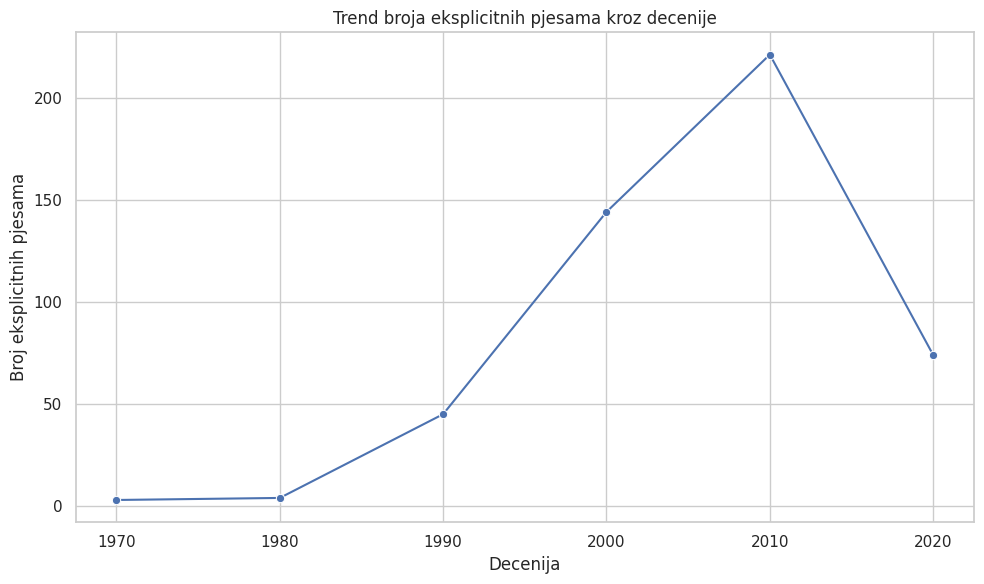

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=trend_eksplicitnih,
    x="Decenija",
    y="Broj eksplicitnih pjesama",
    marker="o"
)

plt.title("Trend broja eksplicitnih pjesama kroz decenije")
plt.xlabel("Decenija")
plt.ylabel("Broj eksplicitnih pjesama")
plt.tight_layout()
plt.show()

### Zaključak

Linijski dijagram prikazuje kako se broj eksplicitnih pjesama mijenjao kroz decenije. Ako je u novijim decenijama prisutan rast, to može ukazivati na promjene u muzičkoj industriji, publici i veću prihvaćenost eksplicitnog sadržaja.

## Završni zaključak

Na osnovu sprovedene analize skupa podataka **Spotify Top 10000**, moguće je izdvojiti najpopularnije pjesme, identifikovati izvođače sa najvećim brojem pjesama i uočiti promjene u prisustvu eksplicitnog sadržaja kroz vrijeme.

Osnovni pregled podataka pokazao je strukturu i relevantne kolone za analizu, dok je pregled top pjesama omogućio uvid u numere sa najvišom vrijednošću popularnosti. Analiza izvođača pokazala je koji su autori najzastupljeniji u datasetu, a analiza eksplicitnih pjesama kroz decenije ukazala je na moguće promjene u trendovima muzičke produkcije i sadržaja.

Google Colab se pokazao kao praktično cloud okruženje za rad sa podacima, dok Kaggle omogućava jednostavan pristup javno dostupnim skupovima podataka.